---
# 1.1 필요 라이브러리 및 폰트 로드

In [3]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


# 1.2 데이터 로드

In [4]:
# 1. 원본 데이터 로드
df_original = pd.read_csv("DieCasting_Quality_Raw_Data.csv", header=[0,1])

# 제품 타입 1번 데이터 추출
df_product_1 = df_original.loc[df_original[('Process', 'Product_Type')] == 1].copy()

# 제품 타입 2번 데이터 추출
df_product_2 = df_original.loc[df_original[('Process', 'Product_Type')] == 2].copy()

# 2. 컬럼명 중 첫번째 행을 기준으로 컬럼 분리
process_cols = [col for col in df_product_2.columns if col[0] == 'Process']
sensor_cols = [col for col in df_product_2.columns if col[0] == 'Sensor']
defects_cols = [col for col in df_product_2.columns if col[0] == 'Defects']

# 3. 첫 번째 컬럼을 기준으로 분리된 데이터 프레임 생성
df_process = df_product_2[process_cols].copy()
df_sensor = df_product_2[sensor_cols].copy()
df_defects = df_product_2[defects_cols].copy()

# 4. 두 번째 행에 있는 컬럼명만 사용하도록 변경
# get_level_values(가져오고 싶은 레벨 인덱스) - level 0: 첫번째 행, level 1: 두번째 행
# 왼쪽 .columns: 컬럼명을 바꾸기 위한 설정
# 오른쪽 .columns: 기존 다중레벨 컬럼 가져오기 → get_level_values(1)로 Level 1만 추출
df_process.columns = df_process.columns.get_level_values(1)
df_sensor.columns = df_sensor.columns.get_level_values(1)
df_defects.columns = df_defects.columns.get_level_values(1)

---

# 2 데이터 전처리 (Data Preprocessing)

### 2.1 중복 데이터 확인

In [5]:
# 1. 전체 행에 대한 중복값 확인 -> 완전히 동일한 행이 있는지 확인하는 용도 -> 없음
print(f"전체 행에 대한 데이터 중복값 : {df_original.duplicated().sum()}건")

# 2. ID 기준으로 중복값 확인 -> 설비 ID 중복 확인용 -> 없음
print(f"ID 기준에 대한 중복값 : {df_process.duplicated(subset=["id"]).sum()}건")


전체 행에 대한 데이터 중복값 : 0건
ID 기준에 대한 중복값 : 0건


### 2.3 컬럼 정제

In [6]:
# 1. 공백 제거 및 컬럼명 소문자 통일
df_process.columns = df_process.columns.astype("str").str.strip().str.lower()
df_sensor.columns = df_sensor.columns.astype("str").str.strip().str.lower()
df_defects.columns = df_defects.columns.astype("str").str.strip().str.lower()

In [7]:
# 2. Sensor 데이터프레임에서 _min/_max로 끝나는 컬럼 찾아서 삭제
minmax_cols = [c for c in df_sensor.columns if c.endswith("_min") or c.endswith("_max")]
df_sensor_clean = df_sensor.drop(columns=minmax_cols)


print("삭제한 _min/_max 컬럼 수:", len(minmax_cols))
print("삭제 전 df_sensor shape:", df_sensor.shape)
print("삭제 후 df_sensor shape:", df_sensor_clean.shape)

삭제한 _min/_max 컬럼 수: 8
삭제 전 df_sensor shape: (3328, 14)
삭제 후 df_sensor shape: (3328, 6)


### 2.4 불량 유형 고유값 처리

In [8]:
# 1. 1(고장)이 아닌 유형의 값이 존재하는 컬럼
target_columns = [
    "short_shot_1", "exfoliation_1", "blow_hole_1", "stain_1", "deformation_1",
    "short_shot_2", "bubble_2", "exfoliation_2", "blow_hole_2", "deformation_2"
]
# 2. 1보다 큰 값을 모두 1로 변환
df_defects[target_columns] = df_defects[target_columns].clip(upper=1)

# 3. 결과 확인 <- 모든 컬럼의 고유값이 [0, 1]로 정리되었는지 확인용
print("<1보다 큰 값은 1로 변환한 후, 고유값 확인>")
for col in df_defects:
    print(f"{col}: {df_defects[col].unique()}")

<1보다 큰 값은 1로 변환한 후, 고유값 확인>
short_shot_1: [0 1]
bubble_1: [0 1]
exfoliation_1: [0]
blow_hole_1: [0 1]
stain_1: [0 1]
dent_1: [0 1]
deformation_1: [0]
contamination_1: [0 1]
impurity_1: [0 1]
crack_1: [0 1]
scratch_1: [0 1]
buring_mark_1: [0 1]
inclusions_1: [0]
short_shot_2: [0 1]
bubble_2: [0]
exfoliation_2: [0]
blow_hole_2: [0 1]
stain_2: [0]
dent_2: [0 1]
deformation_2: [0]
contamination_2: [0 1]
impurity_2: [0 1]
crack_2: [0 1]
scratch_2: [0]
buring_mark_2: [0]
inclusions_2: [0 1]


In [9]:
# 4. Cavity 1,2 불량 유형 통합
df_defects_clean =df_defects.copy()

# 4-1. cavity 1/2 컬럼 분리
c1 =df_defects_clean[[c for c in df_defects_clean.columns if c.endswith("_1")]].copy()
c2 =df_defects_clean[[c for c in df_defects_clean.columns if c.endswith("_2")]].copy()

# 4-2. 컬럼명 통일: short_shot_1 -> short_shot
c1.columns = [c.replace("_1", "") for c in c1.columns]
c2.columns = [c.replace("_2", "") for c in c2.columns]

# 4-3. 제대로 분리되었는지 확인
print("c1 shape:", c1.shape)
print("c2 shape:", c2.shape)
print("c1, c2 컬럼이 동일한가?", set(c1.columns) == set(c2.columns))

c1 shape: (3328, 13)
c2 shape: (3328, 13)
c1, c2 컬럼이 동일한가? True


In [10]:
# 4-4. OR 방식으로 통합: 둘 중 하나라도 1이 있다면 1이 입력됨
defects_merged = ((c1 + c2) > 0).astype(int)   # (c1 | c2) 도 가능
df_defects_clean = defects_merged

print("통합 전 df_defects shape:",df_defects.shape)
print("통합 후 df_defects_clean shape:",df_defects_clean.shape)
print("값 종류:", np.unique(df_defects_clean.to_numpy()))
df_defects_clean.head(10)

통합 전 df_defects shape: (3328, 26)
통합 후 df_defects_clean shape: (3328, 13)
값 종류: [0 1]


,short_shot,bubble,exfoliation,blow_hole,stain,dent,deformation,contamination,impurity,crack,scratch,buring_mark,inclusions
4207,0,0,0,0,0,0,0,0,0,0,0,0,0
4208,0,0,0,0,0,0,0,0,0,0,0,0,0
4209,0,0,0,0,0,0,0,0,0,0,0,0,0
4210,0,0,0,0,0,0,0,0,0,0,0,0,0
4211,0,0,0,0,0,0,0,0,0,0,0,0,0
4212,0,0,0,0,0,0,0,0,0,0,0,0,0
4213,0,0,0,0,0,0,0,0,0,0,0,0,0
4214,0,0,0,0,0,0,0,0,0,0,0,0,0
4215,0,0,0,0,0,0,0,0,0,0,0,0,0
4216,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
# 4-5. 전체 셀 기준(모든 defect 칸을 다 펼쳐서 0/1/2 비율)
flat = df_defects_clean.to_numpy().ravel()
dist_all = pd.Series(flat).value_counts(normalize=True).reindex([0,1,2], fill_value=0)
print("<전체 셀 기준 0/1/2 비율>")
print((dist_all * 100).round(2).astype(str) + "%")

<전체 셀 기준 0/1/2 비율>
0    97.62%
1     2.38%
2      0.0%
Name: proportion, dtype: object


### 2.5 불량 유형 분리
- 표면 불량(surface_defect) : 육안으로 확인 가능하지만, 금속의 분리나 갈라짐은 없는 불량        
    - stain(얼룩), dent(찍힘), scratch, burning_mark(소착)

- 구조 불량(structural_defect): 육안으로 금속의 분리·갈라짐이 보이거나, 제품의 강도·기능에 직접 영향을 줄 수 있는 불량 
    - short_shot(미성형), bubble(기포), blow_hole(기공), deformation(변형), crack(균열), exfoliation(박리)

- 이물질 포함 불량(contamination_defect): 원래 포함되면 안 되는 외부 물질이 들어간 불량
    - contamination(오염), impurity(이물), inclusions(개재물)

In [12]:
# 불량 유형 범주화
# 같은 유형의 불량으로 구분된 불량유형이 하나의 shot에 동시에 존재하더라도 1로 처리됨
df_defects_groups = pd.DataFrame(index=df_defects_clean.index)

df_defects_groups["surface_defect"] = ( # 표면과 관련된 불량
    df_defects_clean.reindex(columns=["stain", "dent", "scratch", "burning_mark"], fill_value=0).max(axis=1)
)

df_defects_groups["structural_defect"] = ( # 구조와 관련된 불량
    df_defects_clean.reindex(columns=["short_shot", "bubble", "blow_hole", "deformation", "crack", "exfoliation"], fill_value=0).max(axis=1)
)

df_defects_groups["contamination_defect"] = ( # 이물질이 포함된 불량
    df_defects_clean
    .reindex(columns=["contamination", "impurity", "inclusions"], fill_value=0)
    .max(axis=1)
)


print("df_defects_groups shape:", df_defects_groups.shape)
print('='*30)
print("고유값 종류:", np.unique(df_defects_groups.to_numpy()))
print('='*30)
print("<각 유형별 불량 개수>")
display(df_defects_groups.sum().sort_values(ascending=False)) # 각 유형별 불량 개수
print('='*30)
df_defects_groups.info() # Non-Null인 행의 개수 확인

df_defects_groups shape: (3328, 3)
고유값 종류: [0 1]
<각 유형별 불량 개수>


structural_defect       778
surface_defect          196
contamination_defect     19
dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 3328 entries, 4207 to 7534
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   surface_defect        3328 non-null   int64
 1   structural_defect     3328 non-null   int64
 2   contamination_defect  3328 non-null   int64
dtypes: int64(3)
memory usage: 104.0 KB


### 2.6 Shot ID 컬럼 통합

In [13]:
# 1. "shot_key" 컬럼 생성
df_process_clean =df_process.copy()
df_process_clean["shot_key"] =df_process_clean["id"].astype(str) + "_" + df_process_clean["shot"].astype(str)

# 2. id, Shot 컬럼 삭제
df_process_clean =df_process_clean.drop(columns=["id", "shot"])

# 3. "shot_key" 컬럼을 맨 앞으로 이동
cols = ["shot_key"] + [c for c in df_process_clean.columns if c != "shot_key"]
df_process_clean =df_process_clean[cols]

# 4. "shot_key"가 중복인 값이 있는지 확인
dup =df_process_clean["shot_key"][df_process_clean["shot_key"].duplicated(keep=False)]
print("중복인 값의 개수:", dup.shape[0])

중복인 값의 개수: 0


In [14]:
# 5. "product_type"의 고유값 및 개수 확인 --> 제품 유형별로 분석을 진행하기 위해서
print(df_process["product_type"].value_counts())

product_type
2    3328
Name: count, dtype: int64


In [15]:
# 6. shot_key 컬럼이 추가된 전체 데이터프레임 제작
df_clean = pd.concat([df_process_clean, df_sensor_clean, df_defects_groups], axis=1)

print("df_clean shape:", df_clean.shape)
df_clean.head()

df_clean shape: (3328, 25)


,shot_key,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,surface_defect,structural_defect,contamination_defect
4207,4207011_11,2,0.156,0.166,0.192,2.723,265,0.012,20,357,36.6,0.041,595,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,0,0,0
4208,4208012_12,2,0.157,0.166,0.204,2.730,264,0.014,19,359,36.5,0.040,594,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,0,0,0
4209,4209013_13,2,0.156,0.170,0.204,2.715,265,0.012,18,361,36.5,0.041,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0
4210,4210014_14,2,0.154,0.170,0.202,2.717,264,0.011,20,364,36.5,0.042,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0
4211,4211015_15,2,0.146,0.160,0.198,2.684,264,0.012,20,357,36.5,0.042,595,12.5,2.0,2.2,672.4,6.3,26.2,2.71,33.6,56.4,0,0,0


### 2.8 결측값 처리

In [16]:
# 1. 데이터프레임 내 결측값 확인
na_count = df_clean.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0].sort_values(ascending=False)

print("<그룹별 결측치(전체 결측값의 개수)>")
print(pd.Series({
    "Process": df_process_clean.isna().sum().sum(),
    "Sensor":  df_sensor_clean.isna().sum().sum(),
    "Defects": df_defects_clean.isna().sum().sum()
}))
print()

print('='*30)
print("<결측치가 있는 컬럼 및 결측값의 수>")
print(na_cols.sort_values(ascending=False))
print()

<그룹별 결측치(전체 결측값의 개수)>
Process      0
Sensor     180
Defects      0
dtype: int64

<결측치가 있는 컬럼 및 결측값의 수>
factory_humidity    90
factory_temp        90
dtype: int64



In [17]:
# Sensor 컬럼별 결측치 개수
sensor_na_count = df_sensor_clean.isna().sum()
sensor_na_ratio = df_sensor_clean.isna().mean() * 100

# 결측치가 있는 컬럼만 정리
sensor_na_summary = pd.DataFrame({
    "na_count": sensor_na_count,
    "na_ratio(%)": sensor_na_ratio
})

sensor_na_summary = sensor_na_summary[sensor_na_summary["na_count"] > 0]\
    .sort_values(by="na_count", ascending=False)

print("<Sensor 컬럼별 결측치 개수 / 비율>")
print(sensor_na_summary.round(4))
print()

<Sensor 컬럼별 결측치 개수 / 비율>
                  na_count  na_ratio(%)
factory_temp            90       2.7043
factory_humidity        90       2.7043



In [18]:
# 중앙값으로 채움
fill_cols = ["factory_temp", "factory_humidity"]
df_sensor_clean[fill_cols] = df_sensor_clean[fill_cols].fillna(df_sensor_clean[fill_cols].median())

print(df_sensor_clean[fill_cols].isna().sum())
print("남은 결측 총합:", df_sensor_clean[fill_cols].isna().sum().sum())

factory_temp        0
factory_humidity    0
dtype: int64
남은 결측 총합: 0


### 2.9 이상치 처리

In [19]:
# 1. Process, Sensor 관련 데이터의 기초통계량 확인
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"⬇️{df_name} 관련 데이터의 기초통계량⬇️")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    
    # 1-3. 고유값의 개수, 왜도, 첨도 추가
    stats_df['Unique'] = df_copied.nunique()
    stats_df['Skewness'] = df_copied.skew()
    stats_df['Kurtosis'] = df_copied.kurtosis()
    
    # 1-4. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수', # 결측치가 아닌 값의 개수
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Unique': '고유값',
        'Skewness': '왜도',
        'Kurtosis': '첨도'
    }, inplace=True)
    
    display(stats_df)
    
    return stats_df

z-score 병행 = 왜도 < |2| 첨도 < |8| 만족 못할시 iqr

iqr

처리 방법은 z-score, iqr 모두 클램핑 기법으로 시행

In [20]:
# 2. 함수 실행
stats_df_process = create_statistics_summary(df_process_clean, 'Process', exclude_cols=['product_Type'])
stats_df_sensor = create_statistics_summary(df_sensor_clean, 'Sensor')
stats_df_sensor = create_statistics_summary(df_defects_groups, 'defects')


⬇️Process 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
product_type,3328.0,2.000000,0.000000,2.000,2.0000,2.000,2.000,2.000,1,0.0,0.0
velocity_1,3328.0,0.154473,0.004838,0.139,0.1515,0.156,0.158,0.162,20,-0.723734,-0.280219
velocity_2,3328.0,0.168620,0.004023,0.158,0.1660,0.168,0.172,0.178,16,0.066497,-0.811232
velocity_3,3328.0,0.202247,0.004953,0.184,0.2000,0.202,0.206,0.216,26,-0.215835,0.367787
high_velocity,3328.0,2.553245,0.071882,2.470,2.5140,2.524,2.538,2.744,155,1.57937,0.745153
cylinder_pressure,3328.0,264.764123,0.756067,247.000,265.0000,265.000,265.000,266.000,6,-15.937863,364.73017
rapid_rise_time,3328.0,0.011660,0.000887,0.009,0.0110,0.012,0.012,0.014,6,-0.645471,2.402679
biscuit_thickness,3328.0,17.589243,1.492139,2.000,17.0000,18.000,19.000,24.000,14,-1.538814,14.104029
clamping_force,3328.0,370.342548,10.160827,346.000,361.0000,375.000,379.000,388.000,24,-0.470378,-1.228546
cycle_time,3328.0,35.704838,2.509634,33.600,35.8000,36.000,36.100,125.900,31,28.736696,1008.900533



⬇️Sensor 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
melting_furnace_temp,3328.0,655.703996,8.494439,635.30,648.70,655.4,662.50,678.10,323,0.273951,-0.647366
air_pressure,3328.0,6.120583,0.677288,4.60,5.60,6.2,6.80,7.10,26,-0.378966,-0.930384
coolant_temp,3328.0,26.923347,0.551408,25.90,26.50,26.8,27.30,28.10,23,0.282971,-0.738899
coolant_pressure,3328.0,2.689742,0.056365,2.58,2.63,2.7,2.74,2.79,22,-0.210328,-1.543214
factory_temp,3328.0,32.571725,1.522960,27.40,31.60,32.0,32.50,37.00,67,1.401438,1.016791
factory_humidity,3328.0,63.190775,6.631947,45.50,61.80,64.3,69.10,72.30,210,-1.083763,0.270639



⬇️defects 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
surface_defect,3328.0,0.058894,0.235462,0.0,0.0,0.0,0.0,1.0,2,3.748979,12.062089
structural_defect,3328.0,0.233774,0.423294,0.0,0.0,0.0,0.0,1.0,2,1.258635,-0.416090
contamination_defect,3328.0,0.005709,0.075354,0.0,0.0,0.0,0.0,1.0,2,13.127032,170.421373


## 값 IQR 확인 및 이상치 처리 기준 논의

In [21]:
def check_iqr_detail(df, df_name="df"):
    num_df = df.select_dtypes(include="number")
    
    q1 = num_df.quantile(0.25)
    q3 = num_df.quantile(0.75)
    iqr = q3 - q1
    
    result = pd.DataFrame({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr
    })
    
    print(f"\n[{df_name} 컬럼별 Q1 / Q3 / IQR]")
    print(result)
    
    return result

process_iqr_detail = check_iqr_detail(df_process_clean, "df_process_clean")
sensor_iqr_detail = check_iqr_detail(df_sensor_clean, "df_sensor_clean")


[df_process_clean 컬럼별 Q1 / Q3 / IQR]
                          Q1       Q3      IQR
product_type          2.0000    2.000   0.0000
velocity_1            0.1515    0.158   0.0065
velocity_2            0.1660    0.172   0.0060
velocity_3            0.2000    0.206   0.0060
high_velocity         2.5140    2.538   0.0240
cylinder_pressure   265.0000  265.000   0.0000
rapid_rise_time       0.0110    0.012   0.0010
biscuit_thickness    17.0000   19.000   2.0000
clamping_force      361.0000  379.000  18.0000
cycle_time           35.8000   36.100   0.3000
pressure_rise_time    0.0340    0.040   0.0060
casting_pressure    595.0000  596.000   1.0000
spray_time           12.0000   12.100   0.1000
spray_1_time          2.0000    2.000   0.0000
spray_2_time          2.0000    2.000   0.0000

[df_sensor_clean 컬럼별 Q1 / Q3 / IQR]
                          Q1      Q3    IQR
melting_furnace_temp  648.70  662.50  13.80
air_pressure            5.60    6.80   1.20
coolant_temp           26.50   27.30   0.

cylinder_pressure 값 Q1 = 265, Q3 = 265, IQR = 0

265만 정상으로 판단하고 나머지 값을 전부 이상치로 판단

In [22]:
print(df_process_clean["cylinder_pressure"].value_counts().sort_index())

cylinder_pressure
247       4
262       5
263      22
264     656
265    2639
266       2
Name: count, dtype: int64


spray_1_time, spray_2_time 값 Q1 = 2, Q3 = 2, IQR = 0

2만 정상으로 판단하고 나머지값을 전부 이상치로 판단

In [23]:
print(df_process_clean["spray_1_time"].value_counts().sort_index())

spray_1_time
2.0    3192
2.4      78
2.5      58
Name: count, dtype: int64


In [24]:
print(df_process_clean["spray_2_time"].value_counts().sort_index())

spray_2_time
2.0    2551
2.2      21
2.5      14
2.7     664
3.0      78
Name: count, dtype: int64


IQR = 0이 그 컬럼의 중앙 50% 값이 한 값에 몰려 있다는 뜻이지 그 외의 값이 비정상을 의미하지 않음

IQR=0인 컬럼은 Q1과 Q3가 같아서 허용 범위가 한 값으로 고정되어 그 값이 아닌 나머지 값이 전부 이상치로 잡힌다.\
그리 좋은 현상은 아닌듯하다.


### 클리핑하지 말고 그대로 두기
cylinder_pressure\
spray_1_time\
spray_2_time\
casting_pressure\
rapid_rise_time

설정값 / 단계값 / 이산값 성격이 강해 클리핑 하면 오히려 망가질 가능성이 높음

이건 몇 개의 정해진 값으로 움직이는 컬럼으로 이런 컬럼을 클리핑하면\
전부 대표값으로 눌리거나, 원래 없던 중간값이 발생할수도 있다.

In [25]:
print(df_process_clean["cylinder_pressure"].value_counts().sort_index())

cylinder_pressure
247       4
262       5
263      22
264     656
265    2639
266       2
Name: count, dtype: int64


In [26]:
print(df_process_clean["spray_1_time"].value_counts().sort_index())

spray_1_time
2.0    3192
2.4      78
2.5      58
Name: count, dtype: int64


In [27]:
print(df_process_clean["spray_2_time"].value_counts().sort_index())

spray_2_time
2.0    2551
2.2      21
2.5      14
2.7     664
3.0      78
Name: count, dtype: int64


In [28]:
print(df_process_clean["casting_pressure"].value_counts().sort_index())

casting_pressure
556       4
588       2
589       2
590       1
591       4
592       8
593      28
594     159
595    1446
596    1492
597     182
Name: count, dtype: int64


In [29]:
print(df_process_clean["rapid_rise_time"].value_counts().sort_index())

rapid_rise_time
0.009     120
0.010     163
0.011     740
0.012    2125
0.013      64
0.014     116
Name: count, dtype: int64


### 분포 재확인이 필요
high_velocity\
spray_time\
biscuit_thickness

In [30]:
print(df_process_clean["high_velocity"].value_counts().sort_index())

high_velocity
2.470    2
2.473    2
2.475    2
2.477    2
2.478    2
        ..
2.729    6
2.730    7
2.732    4
2.733    2
2.744    1
Name: count, Length: 155, dtype: int64


In [31]:
print(df_process_clean["spray_time"].value_counts().sort_index())

spray_time
8.0        1
9.9        2
10.0     297
10.1     305
10.2       2
10.3       4
11.1      70
11.9       1
12.0     672
12.1    1418
12.2     461
12.4       7
12.5      14
12.7      14
13.0      49
13.1      11
Name: count, dtype: int64


In [32]:
print(df_process_clean["biscuit_thickness"].value_counts().sort_index())

biscuit_thickness
2       4
11      2
12      2
13     14
14     29
15    170
16    447
17    821
18    975
19    656
20    155
21     46
22      6
24      1
Name: count, dtype: int64


### 상대적으로 연속형에 가까움 전처리 해도 큰 문제가 없을것으로 판단.

velocity_1\
velocity_2\
velocity_3\
clamping_force\
pressure_rise_time\
cycle_time


In [33]:
print(df_process_clean["velocity_1"].value_counts().sort_index())

velocity_1
0.139      2
0.140      4
0.141     18
0.142     35
0.144    100
0.146    110
0.147     60
0.148    158
0.149     63
0.150    282
0.152    278
0.153     30
0.154    310
0.155     99
0.156    393
0.157    128
0.158    683
0.159      1
0.160    504
0.162     70
Name: count, dtype: int64


In [34]:
print(df_process_clean["velocity_2"].value_counts().sort_index())

velocity_2
0.158      2
0.160     34
0.162    208
0.163     36
0.164    411
0.165     83
0.166    488
0.167      2
0.168    499
0.170    503
0.171     95
0.172    360
0.173    124
0.174    319
0.176    126
0.178     38
Name: count, dtype: int64


In [35]:
print(df_process_clean["velocity_3"].value_counts().sort_index())

velocity_3
0.184      6
0.186      8
0.187      1
0.188      9
0.189      5
0.190     40
0.192     50
0.194     96
0.195     40
0.196    121
0.197     79
0.198    345
0.199      2
0.200    506
0.202    507
0.203    118
0.204    379
0.205     85
0.206    401
0.208    254
0.210    148
0.211     10
0.212     75
0.213      3
0.214     33
0.216      7
Name: count, dtype: int64


In [36]:
print(df_process_clean["clamping_force"].value_counts().sort_index())

clamping_force
346     10
348     11
350     29
352     44
354    119
355    236
357    207
359    128
361    129
363    135
364    124
366     91
368     53
370     61
372    123
373    160
375    215
377    402
379    370
381    396
382    240
384     29
386      9
388      7
Name: count, dtype: int64


In [37]:
print(df_process_clean["pressure_rise_time"].value_counts().sort_index())

pressure_rise_time
0.031      4
0.033    374
0.034    480
0.035    542
0.036    918
0.037     37
0.038     30
0.039     72
0.040    263
0.041    277
0.042    316
0.043      3
0.044      8
0.045      4
Name: count, dtype: int64


In [38]:
print(df_process_clean["cycle_time"].value_counts().sort_index())

cycle_time
33.6       2
33.7      29
33.8     113
33.9     216
34.0     207
34.1      34
34.2       7
34.8       1
34.9      24
35.0      44
35.1       2
35.6       6
35.7      58
35.8     284
35.9     506
36.0     752
36.1     848
36.2      82
36.3       9
36.4      12
36.5       8
36.6       9
36.7       6
36.8       1
36.9       9
37.0      46
37.1       4
46.0       1
49.5       2
57.2       4
125.9      2
Name: count, dtype: int64


In [39]:
print(df_process_clean.dtypes)

shot_key               object
product_type            int64
velocity_1            float64
velocity_2            float64
velocity_3            float64
high_velocity         float64
cylinder_pressure       int64
rapid_rise_time       float64
biscuit_thickness       int64
clamping_force          int64
cycle_time            float64
pressure_rise_time    float64
casting_pressure        int64
spray_time            float64
spray_1_time          float64
spray_2_time          float64
dtype: object


In [40]:
def plot_hist_table(df, title=None, exclude_cols=None, n_cols=3, bins=40, kde=True):
    # 원본 복사
    df_copied = df.copy()
    
    # 제외할 컬럼 제거
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    # 숫자형 컬럼 없으면 종료
    if len(cols) == 0:
        print("숫자형 컬럼이 없습니다.")
        return
    
    # subplot 행 개수 계산
    n_rows = (len(cols) - 1) // n_cols + 1
    
    # figure 생성
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 5))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    
    # 컬럼별 히스토그램
    for i, col in enumerate(cols):
        series = df_copied[col].dropna()
        
        sns.histplot(series, kde=kde, color='red', bins=bins, ax=axes[i])
        axes[i].set_title(col, fontsize=15)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")
    
    # 남는 subplot 숨기기
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    # 전체 제목
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

In [41]:
from scipy.stats import shapiro
from scipy import stats
# 테이블(데이터프레임)의 컬럼들로 QQ plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

In [42]:
def plot_box_table(df, title=None, exclude_cols=None, n_cols=3):
    # 원본 복사
    df_copied = df.copy()
    
    # 제외할 컬럼 제거
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    # 숫자형 컬럼 없으면 종료
    if len(cols) == 0:
        print("숫자형 컬럼이 없습니다.")
        return
    
    # subplot 행 개수 계산
    n_rows = (len(cols) - 1) // n_cols + 1
    
    # figure 생성
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 4))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    
    # 컬럼별 박스플롯
    for i, col in enumerate(cols):
        series = df_copied[col].dropna()
        
        sns.boxplot(x=series, color='lightblue', ax=axes[i])
        axes[i].set_title(col, fontsize=12)
        axes[i].set_xlabel("")
    
    # 남는 subplot 숨기기
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    # 전체 제목
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

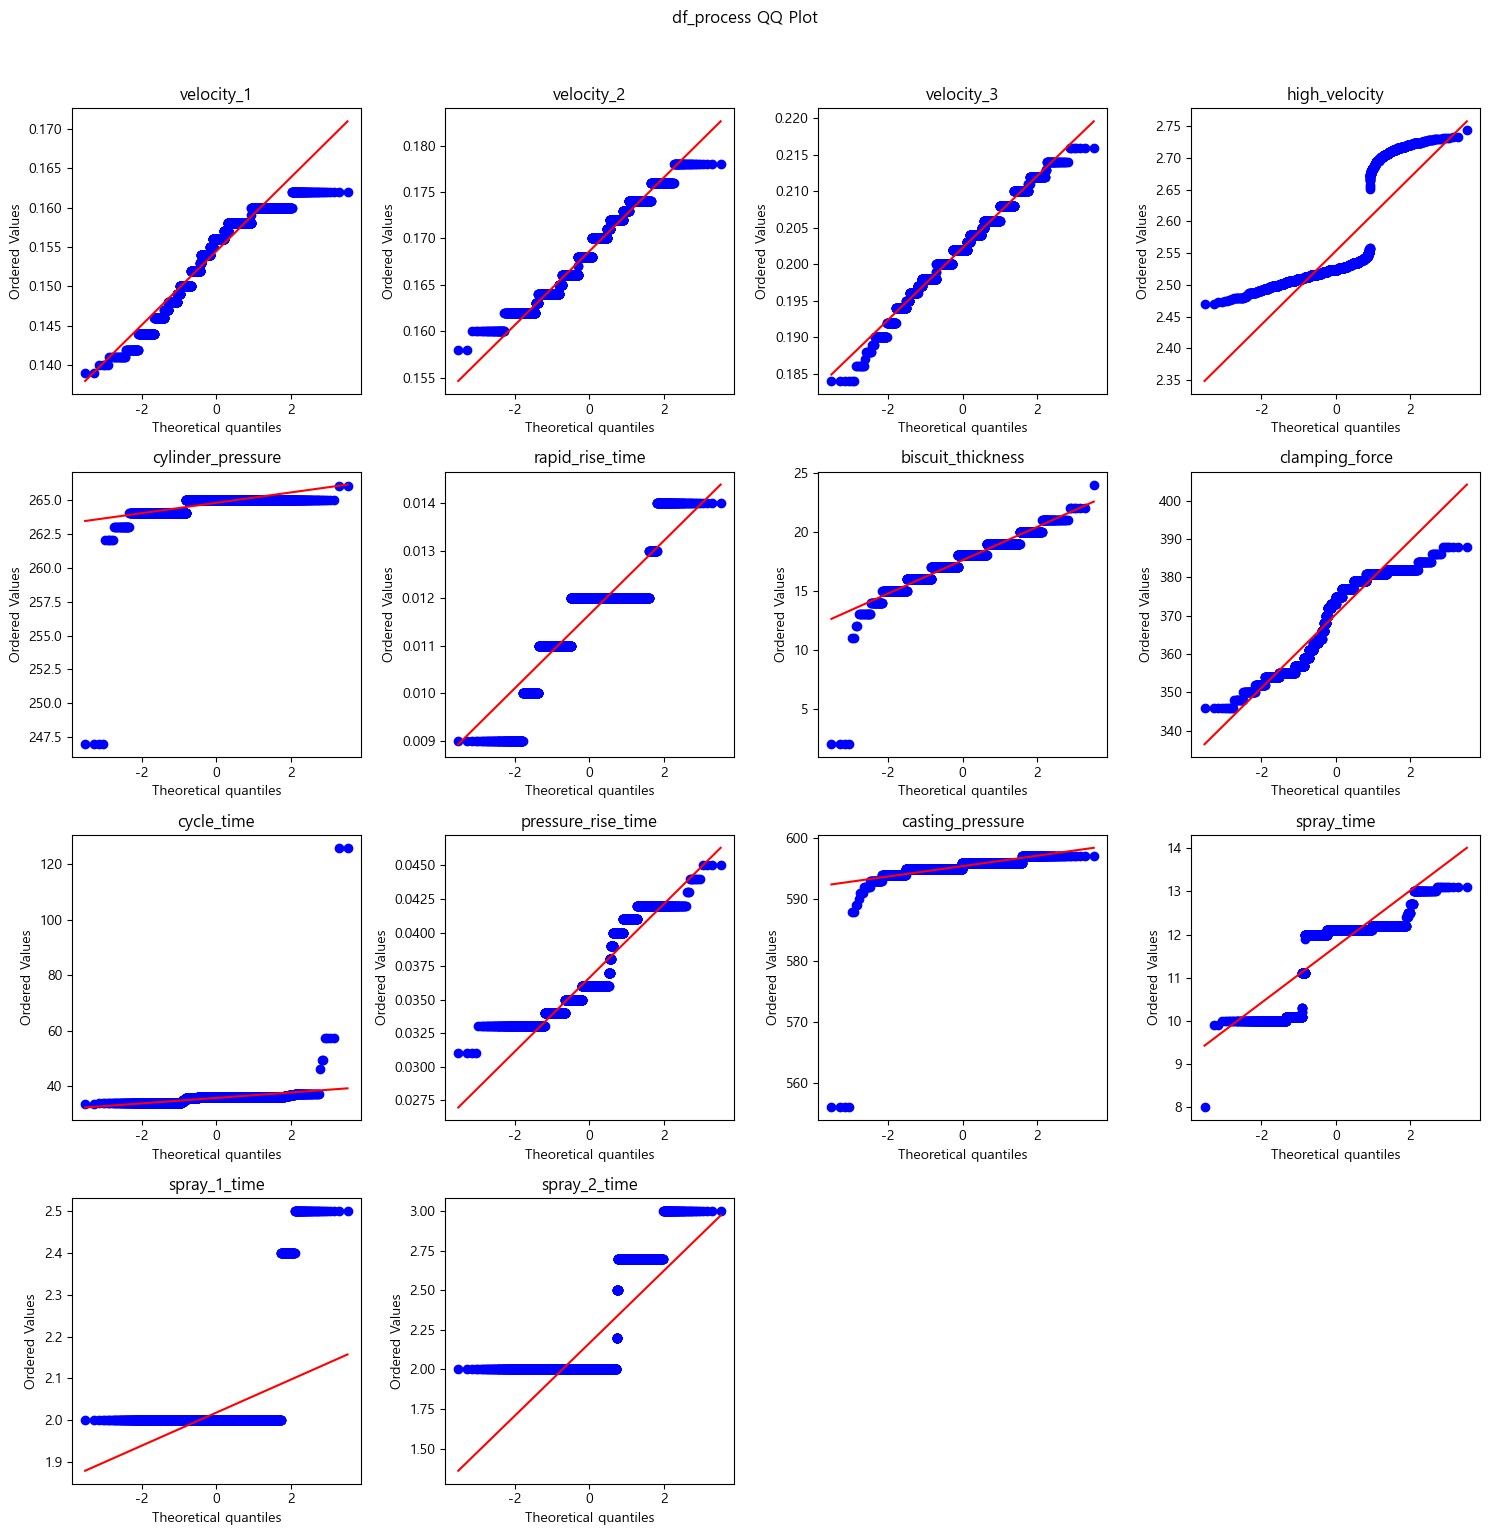

In [43]:
plot_qq_table(df_process_clean, title="df_process QQ Plot", exclude_cols =["product_type"])

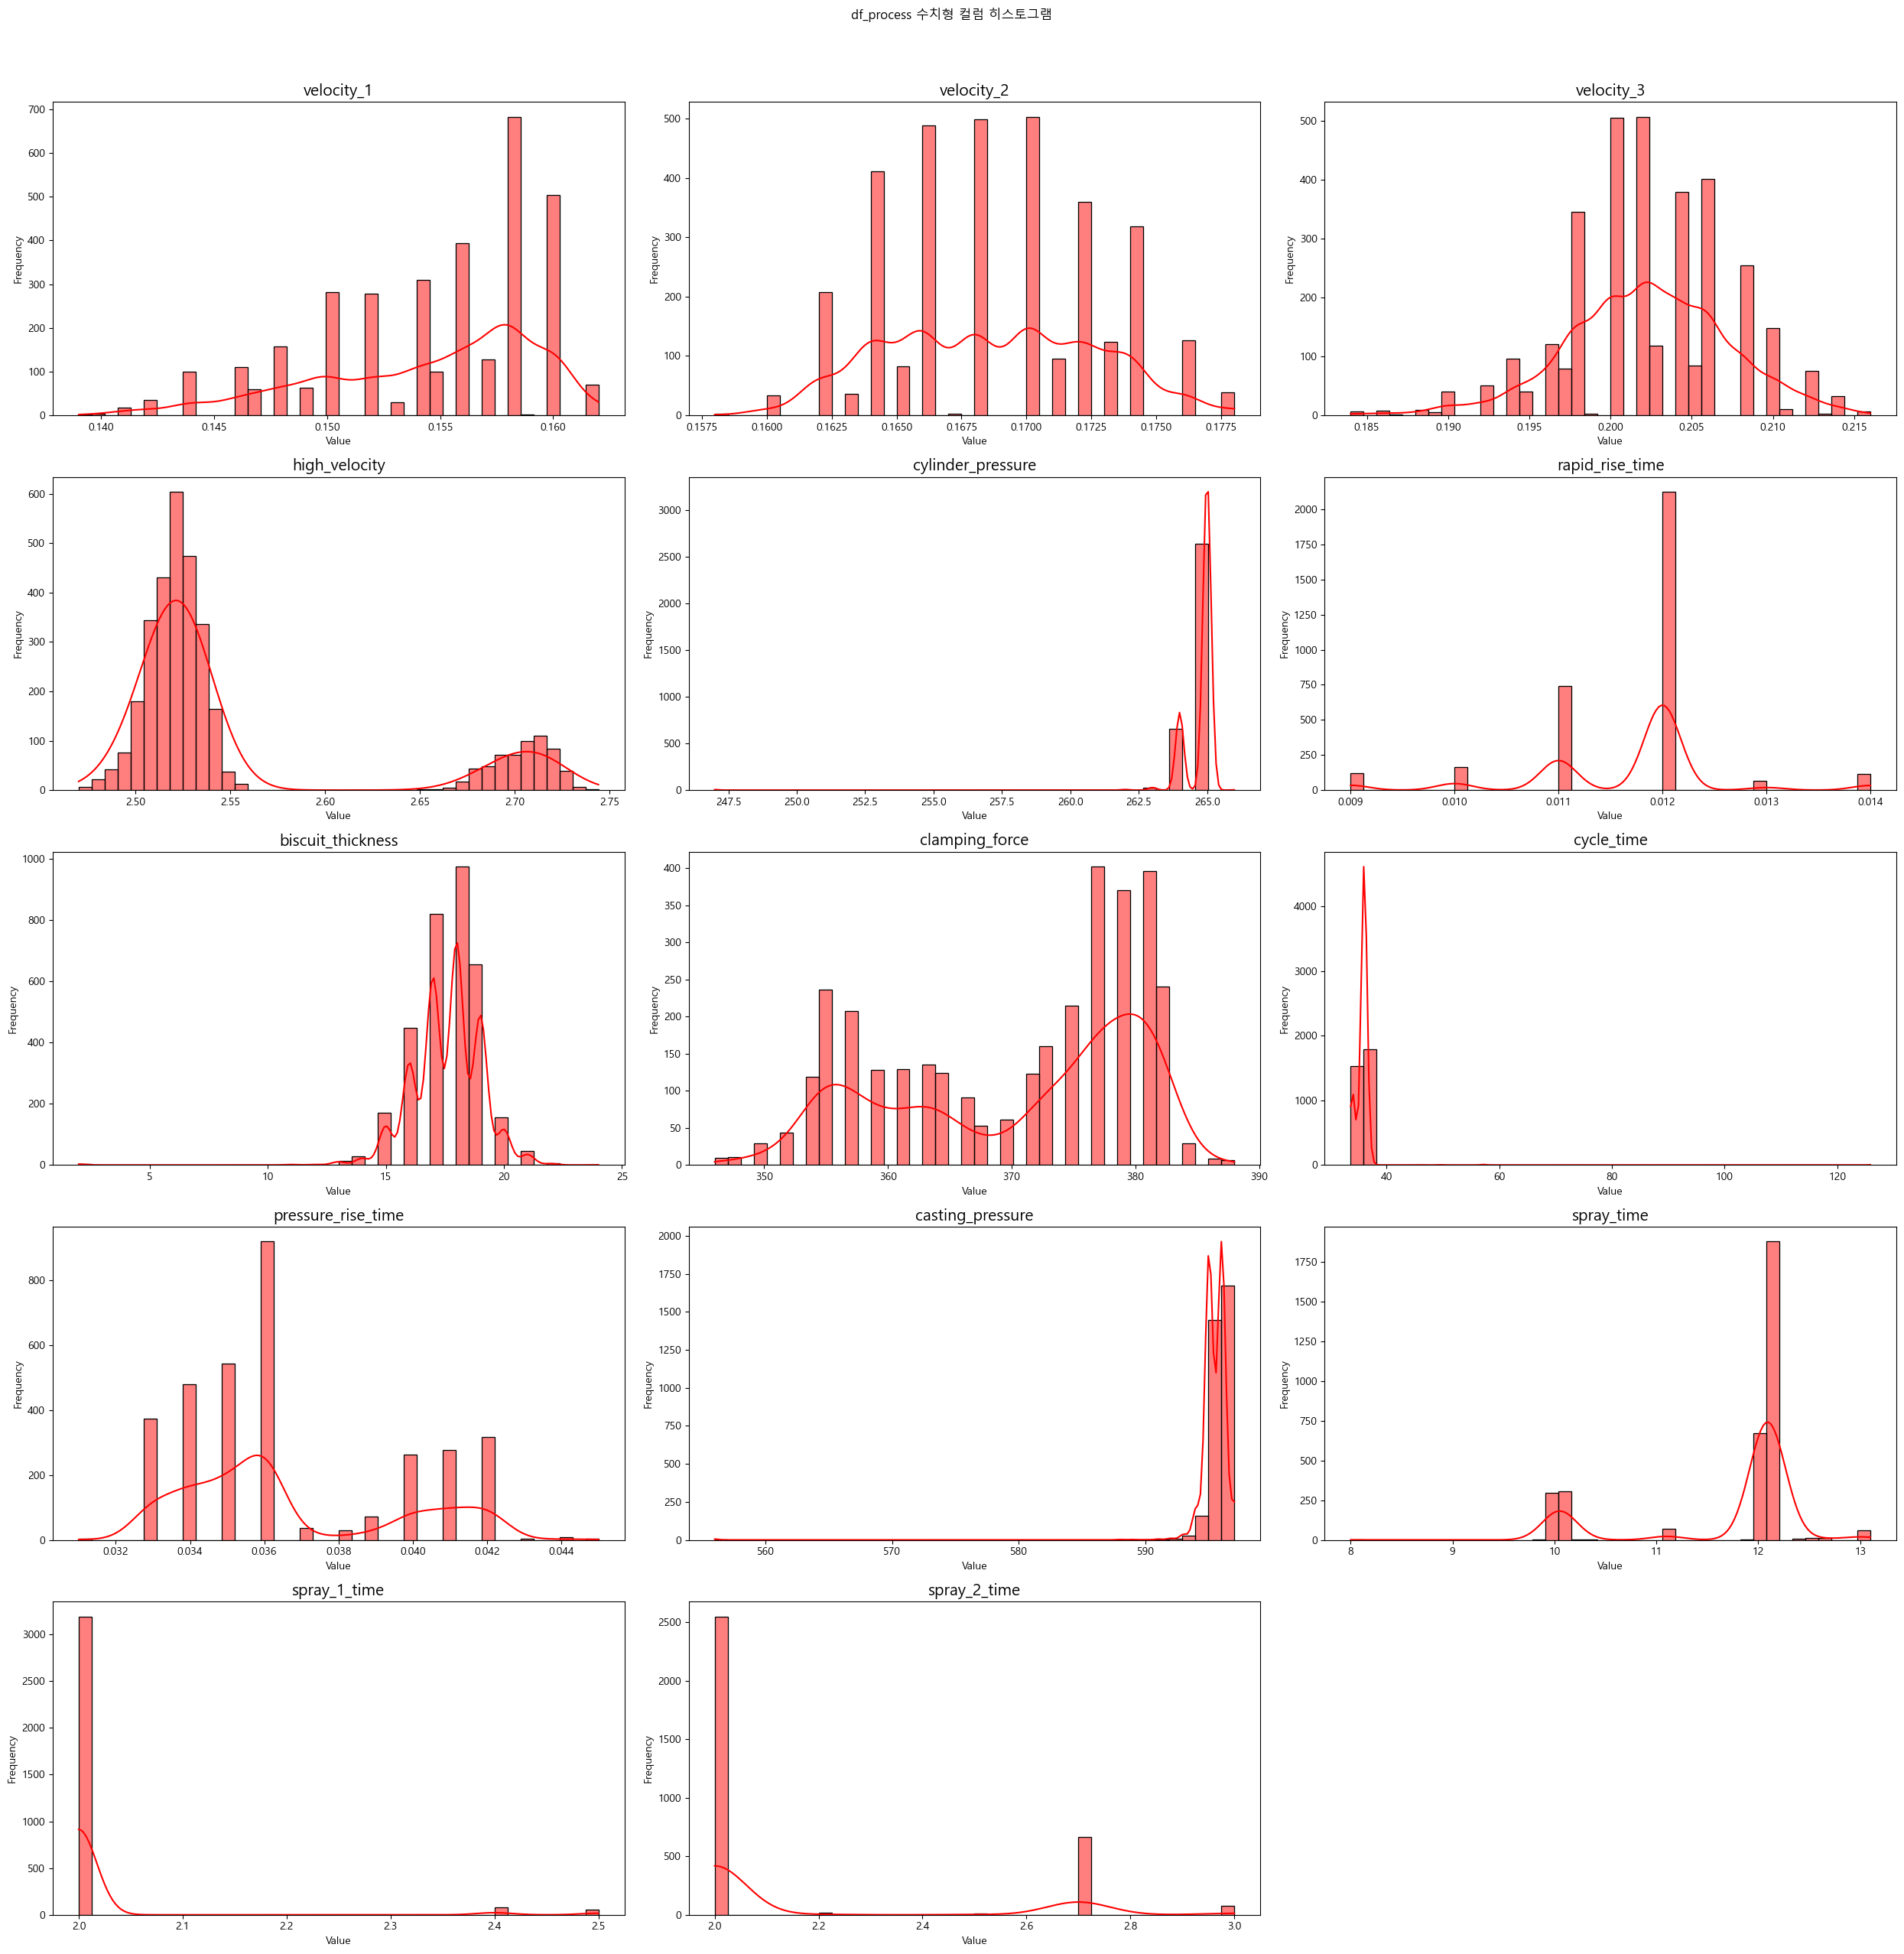

In [44]:
plot_hist_table(df_process_clean, title="df_process 수치형 컬럼 히스토그램", exclude_cols=["product_type"])

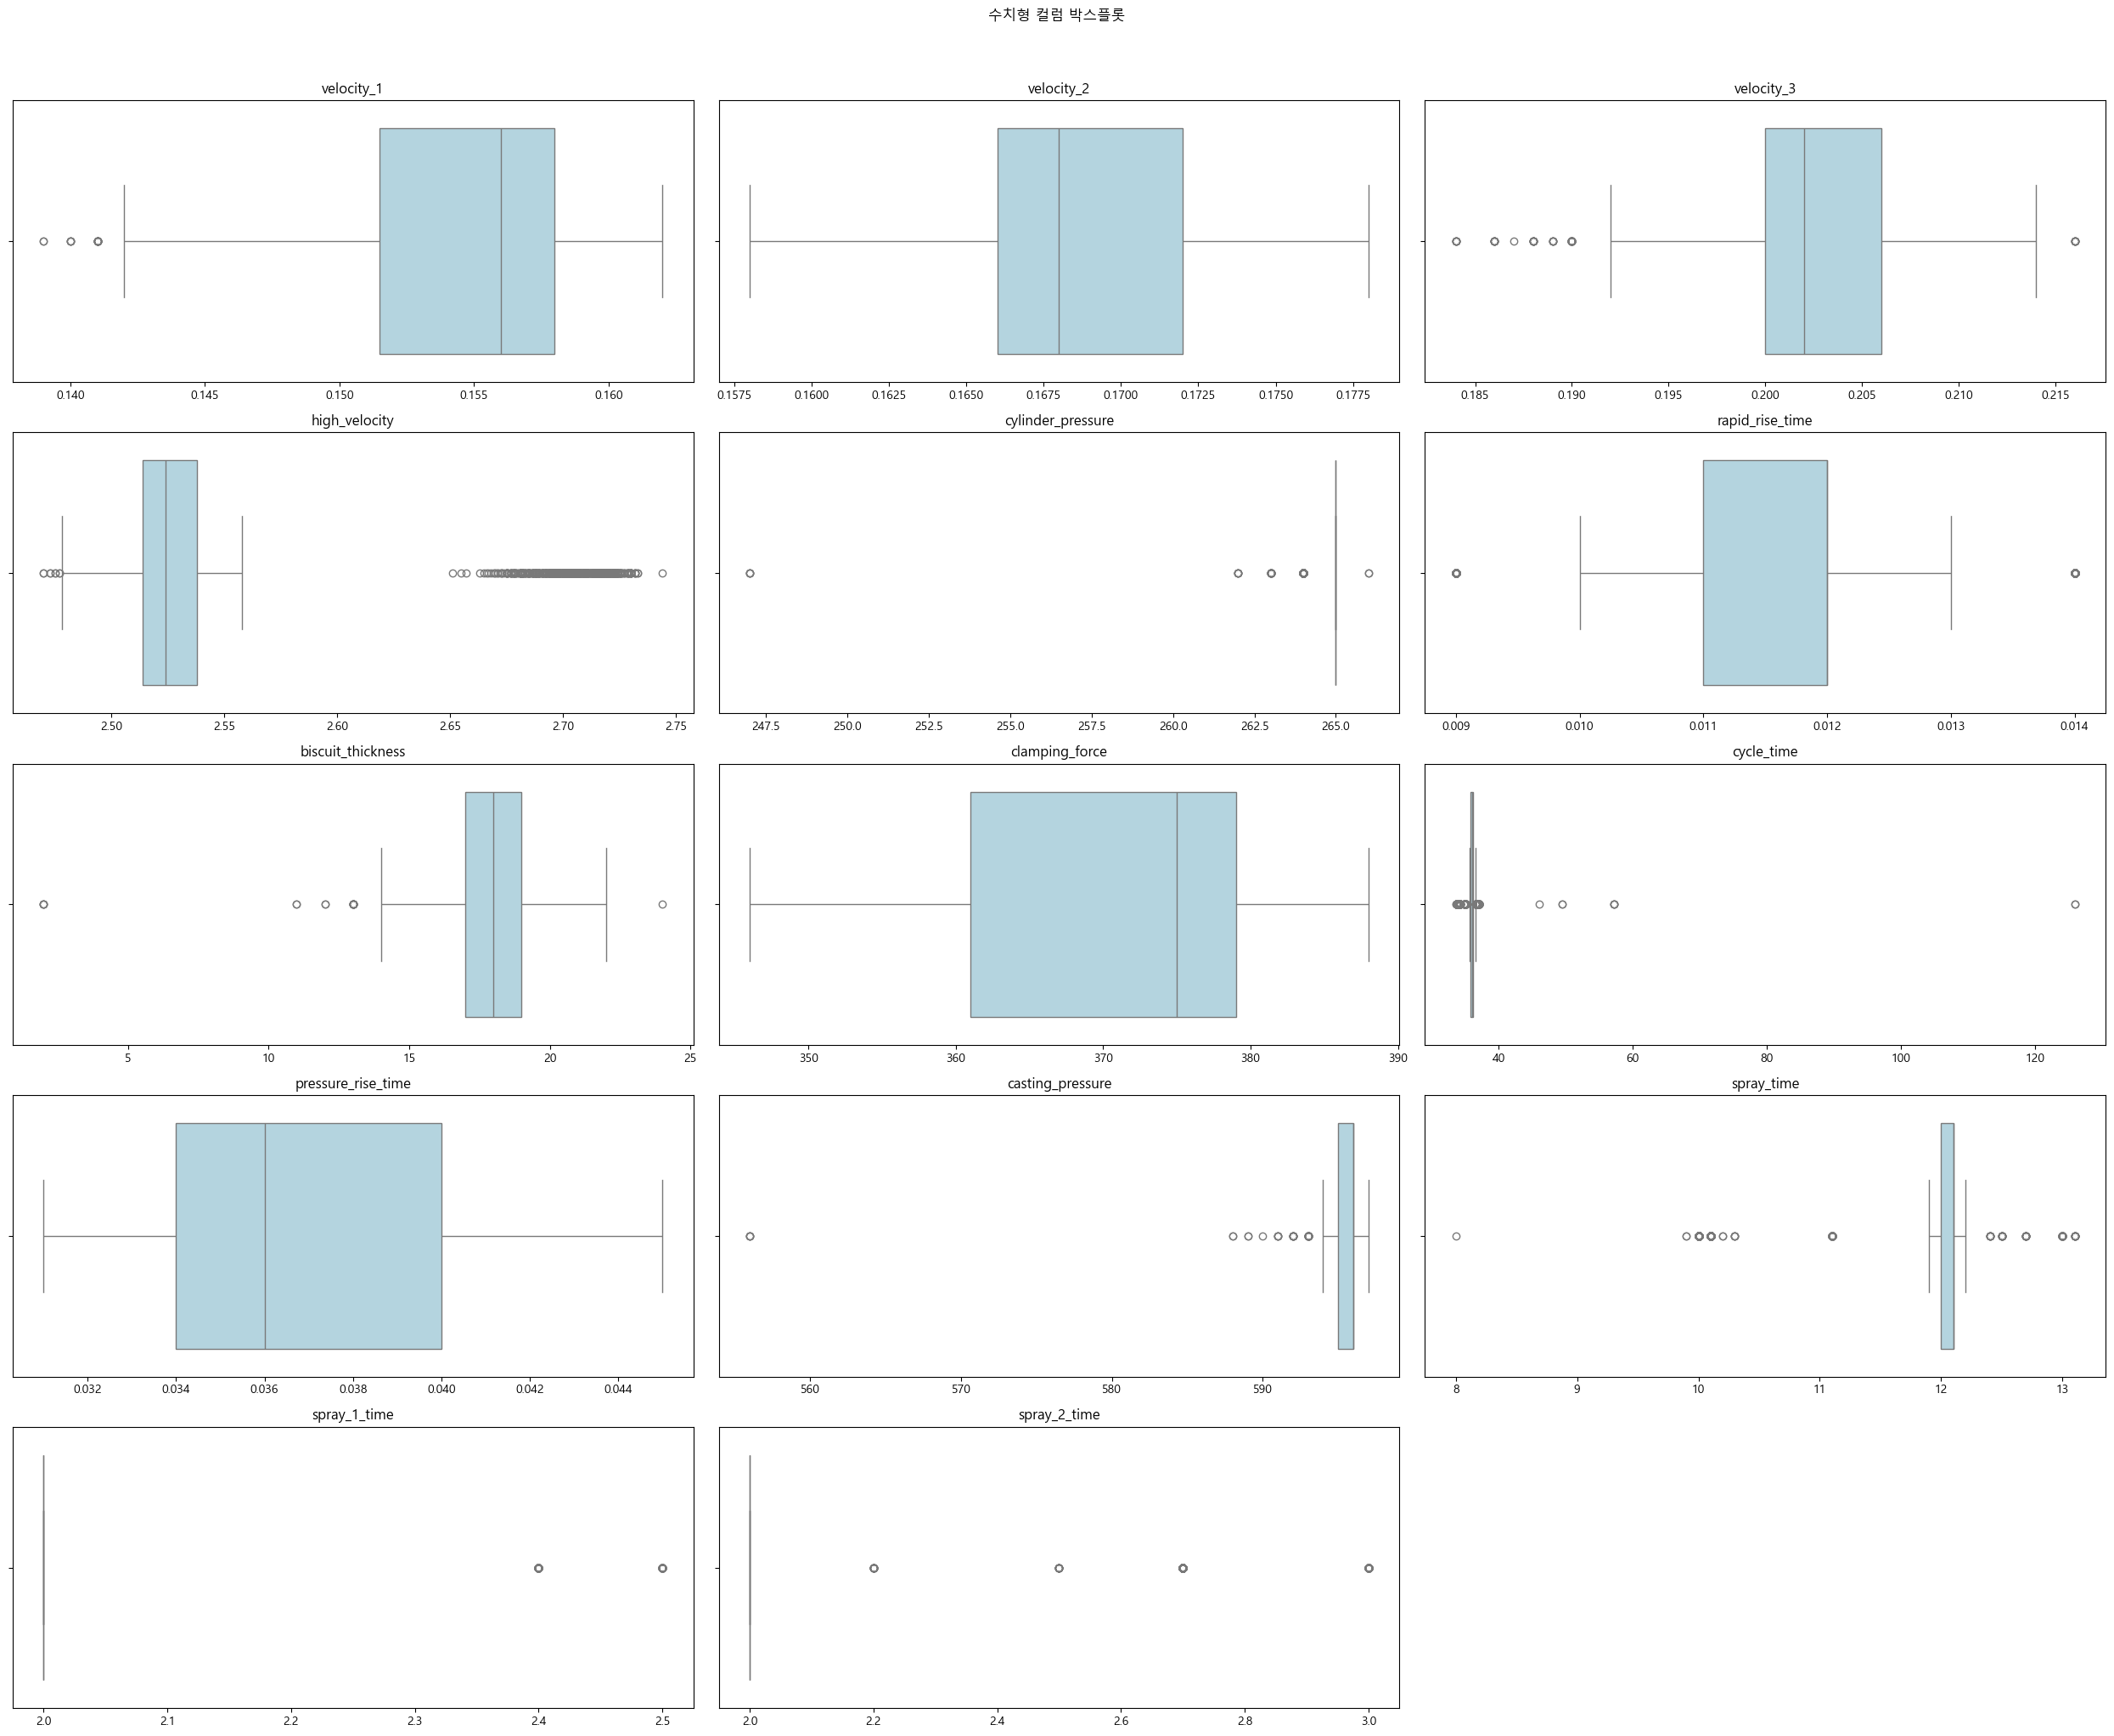

In [45]:
plot_box_table(df_process_clean, title="수치형 컬럼 박스플롯", exclude_cols=["product_type"])

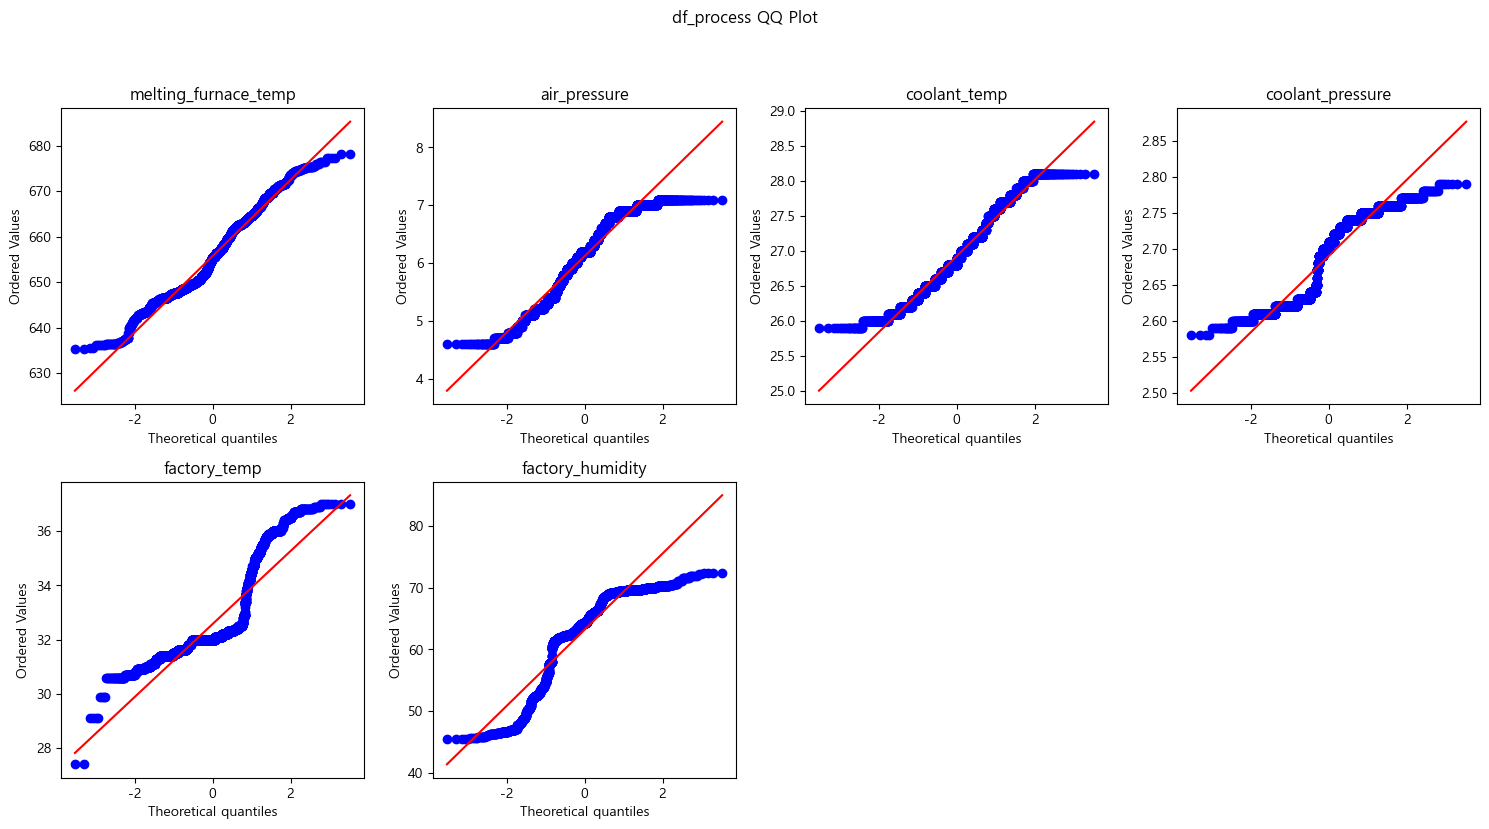

In [46]:
plot_qq_table(df_sensor_clean, title="df_process QQ Plot")

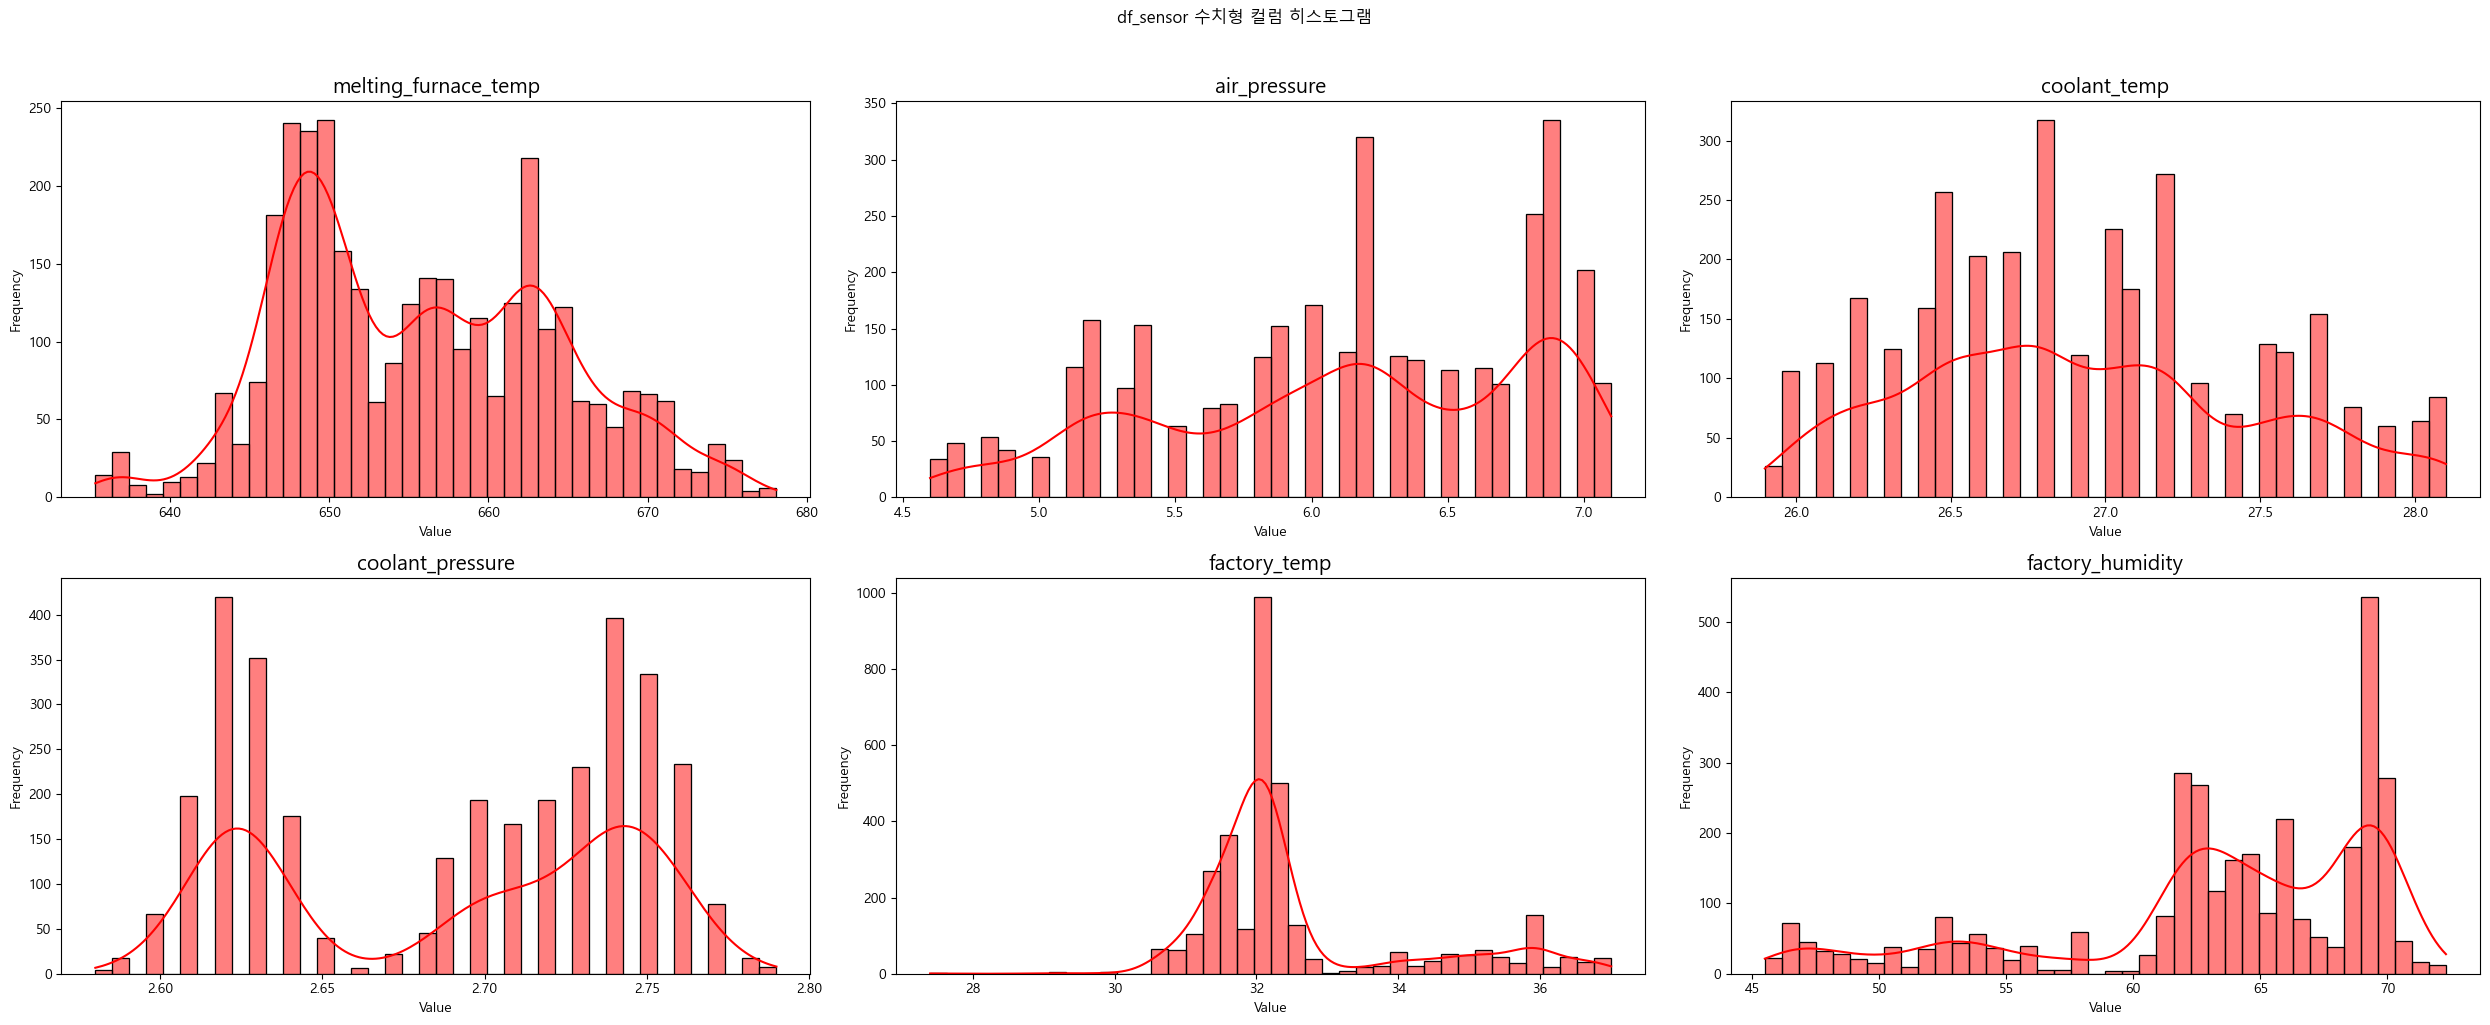

In [47]:
plot_hist_table(df_sensor_clean, title="df_sensor 수치형 컬럼 히스토그램")

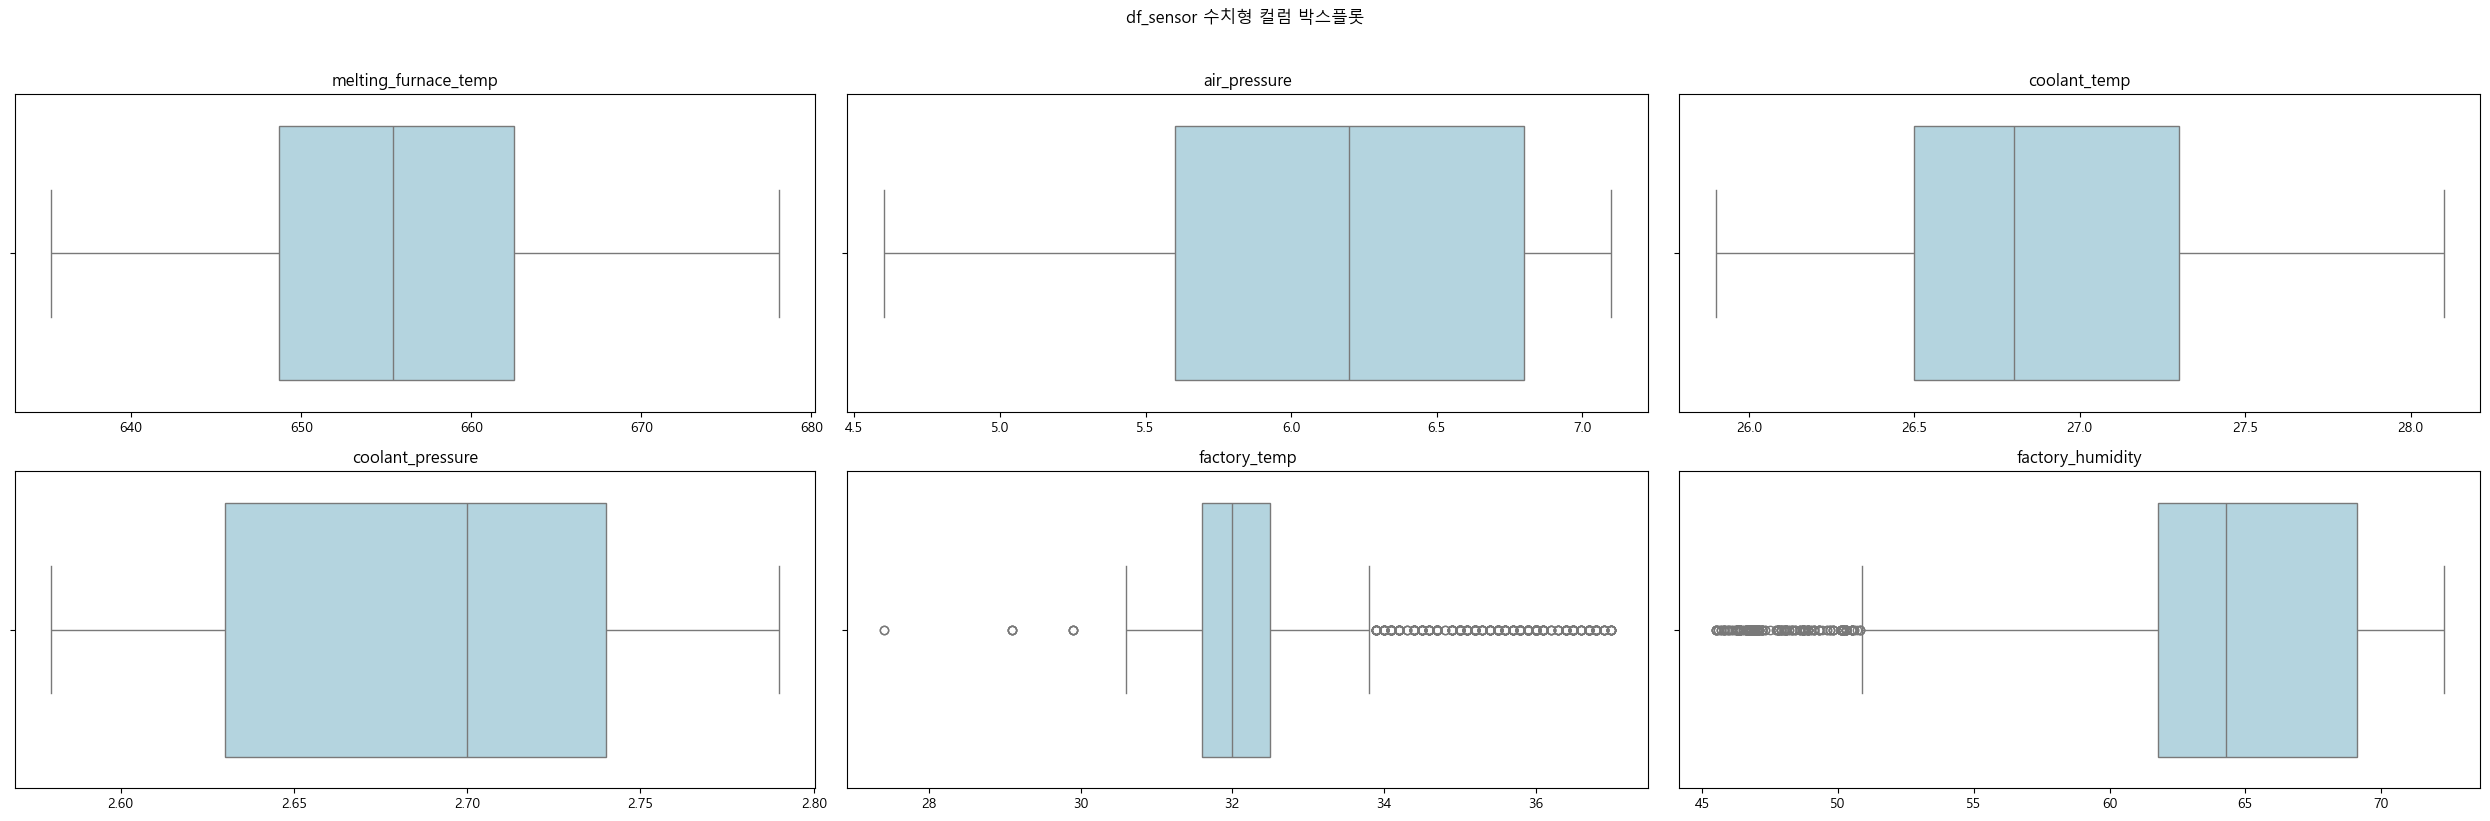

In [48]:
plot_box_table(df_sensor_clean, title="df_sensor 수치형 컬럼 박스플롯")

### 처리 결론 및 제안

#### 제거
velocity_1, velocity_2, velocity_3, clamping_force, pressure_rise_time, cycle_time\
공정값으로 극단값이 공정 노이즈/기록 오차일 가능성이 있어, 클램핑으로 완화해도 해석 손실이 비교적 적을것 같다.\

velocity_1, velocity_2, velocity_3 → 사출 속도 계열 (연속형)\
clamping_force → 금형을 밀어주는 힘으로 연속형 공정\
pressure_rise_time → 주조 압력 상승 시간으로 연속형\
cycle_time → 제품이 나오기까지의 총 시간으로 연속형


#### 그냥 두기? = 설정값/단계값 성격이 강
high_velocity, spray_time, biscuit_thickness, cylinder_pressure, casting_pressure, spray_1_time, spray_2_time, rapid_rise_time\


high_velocity, spray_time → 설정값에 가깝지 않나?\
biscuit_thickness → ?? 공정 관련된 값이라서 그대로 날리긴 애매한데\



확정적으로 제외
cylinder_pressure, casting_pressure → 압력값, 수치 자체가 딱 떨어지는걸 보면 설정값이지 않을까 싶음




#### 애매함.
spray_1_time, spray_2_time, rapid_rise_time →


q1, q3 동일하면 분석에 의미가 없다?
히스토그램으로도 확인해보기
밀도 플랏도 확인해보기

이상치처리를 안하는것도 방법이다.

특성마다 각각 맞는 전처리()

### 2.9.1 process와 sensor의 target(defect) 상관관계 확인

<Process vs Defects>


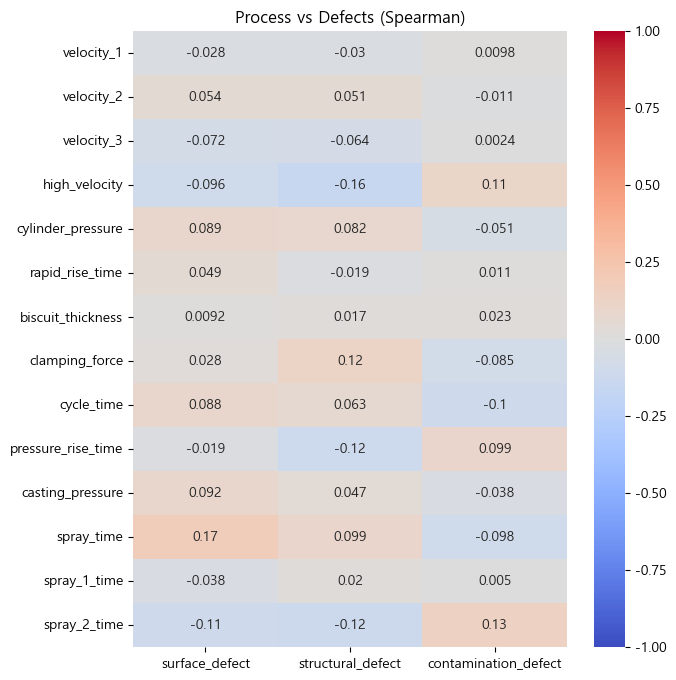

<Sensor vs Defects>


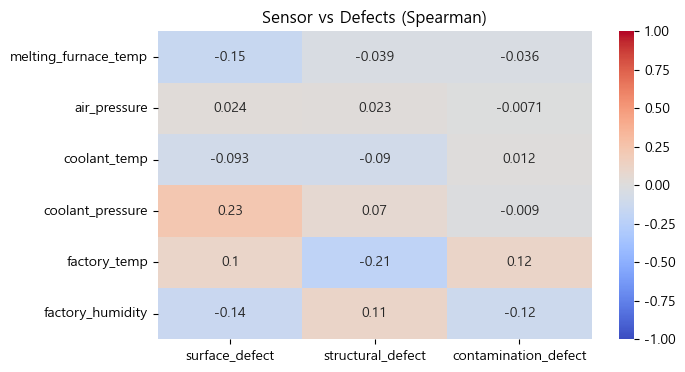

In [49]:
process_cols = [
    'velocity_1', 'velocity_2', 'velocity_3',
    'high_velocity', 'cylinder_pressure', 'rapid_rise_time',
    'biscuit_thickness', 'clamping_force', 'cycle_time',
    'pressure_rise_time', 'casting_pressure', 'spray_time',
    'spray_1_time', 'spray_2_time'
]

sensor_cols = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp',
    'coolant_pressure', 'factory_temp', 'factory_humidity'
]

target_cols = ["surface_defect", "structural_defect", "contamination_defect"]

# 1. 공정 변수 vs 불량
corr_process = df_clean[process_cols + target_cols].corr(method="spearman").loc[process_cols, target_cols]

print("<Process vs Defects>")
plt.figure(figsize=(7, 8))
sns.heatmap(corr_process, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Process vs Defects (Spearman)")
plt.show()


# 2. 센서 변수 vs 불량
corr_sensor = df_clean[sensor_cols + target_cols].corr(method="spearman").loc[sensor_cols, target_cols]

print("<Sensor vs Defects>")
plt.figure(figsize=(7, 4))
sns.heatmap(corr_sensor, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Sensor vs Defects (Spearman)")
plt.show()

In [50]:
df_clean_2 = pd.concat([df_process_clean, df_sensor_clean, df_defects_groups], axis=1)

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score

# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df = pd.concat([df_process_clean, df_sensor_clean, df_defects_groups], axis=1)


# 머신러닝
defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']
df['defect'] = df[defect_cols].max(axis=1)

# 1. 피처 / 레이블 분리 (defect는 평가용으로만 사용)
X = df.drop(columns=defect_cols + ['defect'])  # 공정 + 센서 변수만
y = df['defect']                                # 학습 X, 평가만 사용

# 2. Train / Test 분할 (stratify는 y 기준 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 스케일링
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. 모델 학습 (contamination은 고정값 사용 - 레이블 미사용)
model = IsolationForest(
    n_estimators=100,
    contamination='auto',  # 레이블을 학습에 안 쓰므로 auto
    random_state=42
)
model.fit(X_train_scaled)  # 레이블 없이 X만으로 학습

# 5. 평가 (불량 레이블로 탐지 성능 검증)
preds        = model.predict(X_test_scaled)
preds_binary = (preds == -1).astype(int)
scores       = -model.decision_function(X_test_scaled)

print(classification_report(y_test, preds_binary, target_names=['정상', '불량']))
print(f"AUC-ROC: {roc_auc_score(y_test, scores):.4f}")

              precision    recall  f1-score   support

          정상       0.70      0.81      0.75       477
          불량       0.22      0.14      0.17       189

    accuracy                           0.62       666
   macro avg       0.46      0.47      0.46       666
weighted avg       0.56      0.62      0.59       666

AUC-ROC: 0.4298


### GPT 왈
이상치 없다는데?